# a machine learning try on PIMA diabetes dataset

In [1]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('PIMA_diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## lets see a general analysis of columns informations

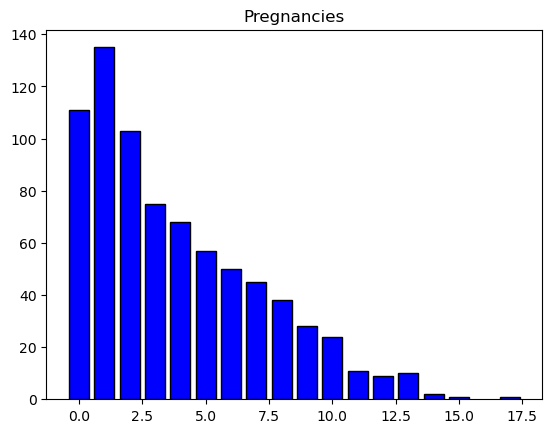

<class 'pandas.core.series.Series'>
RangeIndex: 768 entries, 0 to 767
Series name: Pregnancies
Non-Null Count  Dtype
--------------  -----
768 non-null    int64
dtypes: int64(1)
memory usage: 6.1 KB
None


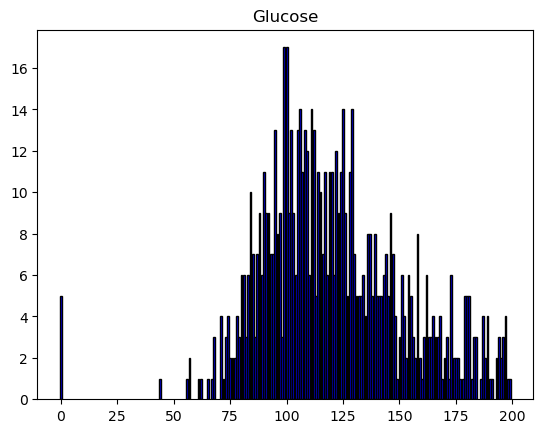

<class 'pandas.core.series.Series'>
RangeIndex: 768 entries, 0 to 767
Series name: Glucose
Non-Null Count  Dtype
--------------  -----
768 non-null    int64
dtypes: int64(1)
memory usage: 6.1 KB
None


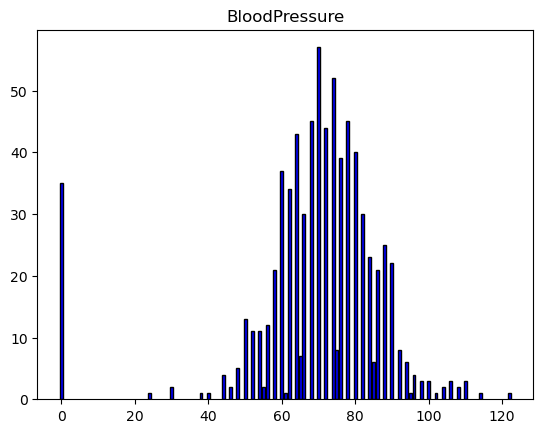

<class 'pandas.core.series.Series'>
RangeIndex: 768 entries, 0 to 767
Series name: BloodPressure
Non-Null Count  Dtype
--------------  -----
768 non-null    int64
dtypes: int64(1)
memory usage: 6.1 KB
None


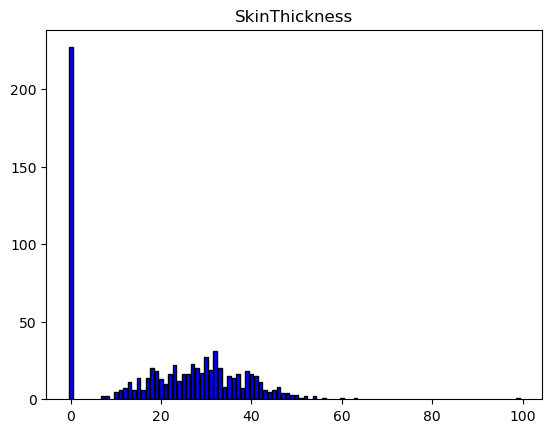

<class 'pandas.core.series.Series'>
RangeIndex: 768 entries, 0 to 767
Series name: SkinThickness
Non-Null Count  Dtype
--------------  -----
768 non-null    int64
dtypes: int64(1)
memory usage: 6.1 KB
None


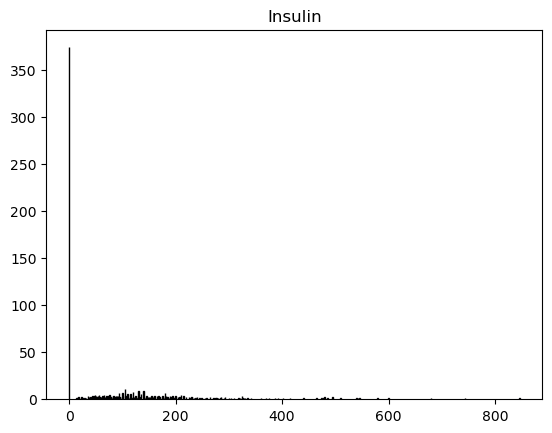

<class 'pandas.core.series.Series'>
RangeIndex: 768 entries, 0 to 767
Series name: Insulin
Non-Null Count  Dtype
--------------  -----
768 non-null    int64
dtypes: int64(1)
memory usage: 6.1 KB
None


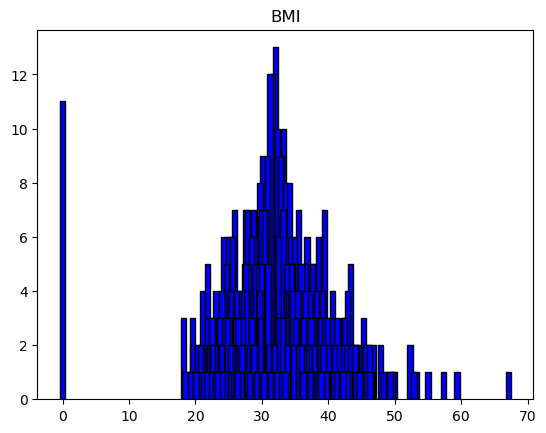

<class 'pandas.core.series.Series'>
RangeIndex: 768 entries, 0 to 767
Series name: BMI
Non-Null Count  Dtype  
--------------  -----  
768 non-null    float64
dtypes: float64(1)
memory usage: 6.1 KB
None


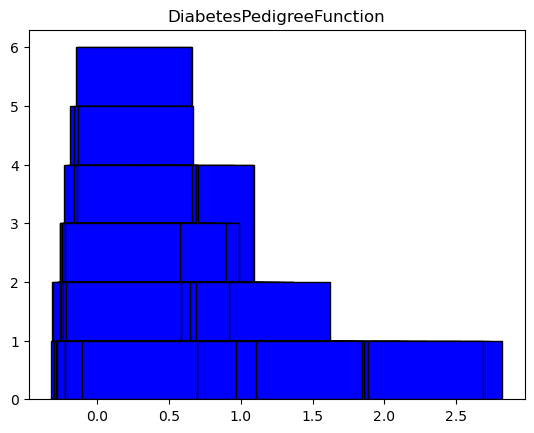

<class 'pandas.core.series.Series'>
RangeIndex: 768 entries, 0 to 767
Series name: DiabetesPedigreeFunction
Non-Null Count  Dtype  
--------------  -----  
768 non-null    float64
dtypes: float64(1)
memory usage: 6.1 KB
None


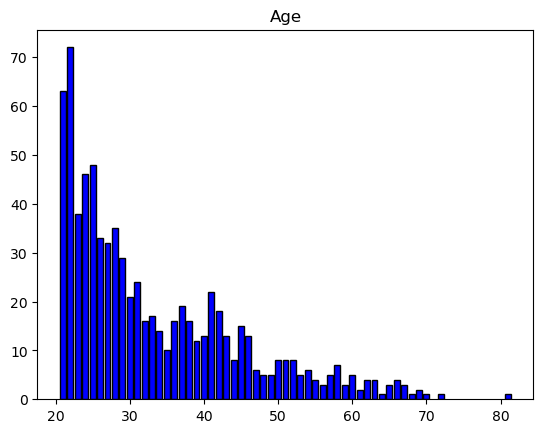

<class 'pandas.core.series.Series'>
RangeIndex: 768 entries, 0 to 767
Series name: Age
Non-Null Count  Dtype
--------------  -----
768 non-null    int64
dtypes: int64(1)
memory usage: 6.1 KB
None


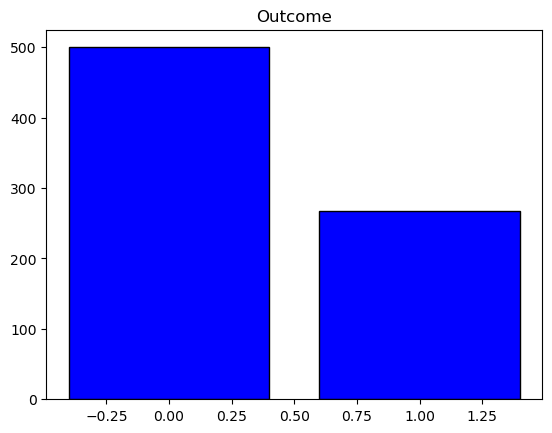

<class 'pandas.core.series.Series'>
RangeIndex: 768 entries, 0 to 767
Series name: Outcome
Non-Null Count  Dtype
--------------  -----
768 non-null    int64
dtypes: int64(1)
memory usage: 6.1 KB
None


In [4]:
import matplotlib.pyplot as plt

cols = ['Pregnancies' , 'Glucose' , 'BloodPressure'	, 'SkinThickness' , 'Insulin' , 'BMI' , 'DiabetesPedigreeFunction' , 'Age' , 'Outcome']
for col in cols:
    plt.bar(df[col].value_counts().index , df[col].value_counts() , color='blue' , edgecolor='black')
    plt.title(col)
    plt.show()
    print(df[col].info())
    print('=' * 100)

#### you can see some impossible values in some columns. like GLucose and BMI. they can not be true biologically
#### let's change this values with nan to make some edits on them in future codes.

## preprocessing and feature engineering

In [5]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    df[cols] = df[cols].replace(0, np.nan)

In [6]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

#### as you can see we have a big imbalance between two labels of this data. so we should making a balance condition for training models. we should be take care to this note that don't make data leakage.

In [7]:
from sklearn.model_selection import train_test_split

x = df[['Pregnancies' , 'Glucose' , 'BloodPressure'	,
        'SkinThickness' , 'Insulin' , 'BMI' ,
        'DiabetesPedigreeFunction' , 'Age'
       ]]
y = df['Outcome']

X_train , X_test , y_train , y_test = train_test_split(x, y, test_size=0.25, random_state=0)

#### we use KNNImputer to impute nan values we maked in last codes

In [8]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values=np.nan, strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

#### and now we use KMeanSmote for training data.attention to dataleakage is so important

In [9]:
from sklearn.cluster import MiniBatchKMeans
from imblearn.over_sampling import KMeansSMOTE

smoter = KMeansSMOTE(
    kmeans_estimator=MiniBatchKMeans(
        n_init=1,
        random_state=0
    ),
    random_state=0,
    k_neighbors=5
)

X_train, y_train = smoter.fit_resample(X_train, y_train)

# تبدیل دوباره به DataFrame
X_train = pd.DataFrame(X_train, columns=x.columns)
X_test = pd.DataFrame(X_test, columns=x.columns)

In [10]:
X_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000
mean,4.213594,130.213925,74.282716,29.794241,141.379203,33.514317,0.479230,35.283185
std,3.548421,31.471421,11.553584,8.379050,79.330020,7.015902,0.315721,12.168684
min,0.000000,56.000000,30.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,105.000000,68.000000,26.575904,127.500000,28.800000,0.252505,25.000000
50%,3.179374,129.000000,74.000000,30.000000,127.500000,33.300000,0.401000,32.000000
75%,6.975356,154.000000,82.000000,32.000000,129.007149,37.400000,0.624401,43.000000
max,17.000000,198.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [11]:
y_train.value_counts()

Outcome
1    373
0    370
Name: count, dtype: int64

In [12]:
y_test.value_counts()

Outcome
0    130
1     62
Name: count, dtype: int64

##### smoter just used for training data

#### and now a little feature engineering

In [13]:
from sklearn.feature_selection import f_classif

f_statistic, p_values = f_classif(X_train, y_train)

In [14]:
f_statistic

array([ 46.16718936, 436.60320595,  41.83995963,  21.79970393,
        14.29956211, 108.16569729,  20.83173468,  83.64544984])

In [15]:
p_values

array([2.23180676e-11, 1.39276623e-76, 1.79858593e-10, 3.59270161e-06,
       1.68456563e-04, 9.69094040e-24, 5.86897626e-06, 5.61549400e-19])

In [16]:
X_train["a"] = np.log(X_train["Age"] * X_train["BMI"])
X_test["a"] = np.log(X_test["Age"] * X_test["BMI"])

X_train["b"] = np.log(X_train["Insulin"])
X_test["b"] = np.log(X_test["Insulin"])

bins = [0, 18, 25, 30, 35, 40, np.inf]

X_train["age_Group"] = pd.cut(
    X_train["Age"],
    bins=bins,
    labels=[0,1,2,3,4,5],
    include_lowest=True
).astype(int)

X_test["age_Group"] = pd.cut(
    X_test["Age"],
    bins=bins,
    labels=[0,1,2,3,4,5],
    include_lowest=True
).astype(int)

X_train = X_train.drop(["BMI"], axis=1)
X_test = X_test.drop(["BMI"], axis=1)

#### making new feature specially age groups help us to have better reults

#### let's scaling all columns with StandardScaler

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train, fit and test models

#### we use microsoft flaml AutoMl to find and hyperparameterizing best model

In [18]:
from flaml import AutoML

#AutoML
automl = AutoML()

automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="classification",
    metric="roc_auc",
    time_budget = 60,
    verbose=0
)

In [19]:
# Predictions
y_pred = automl.predict(X_test)
y_prob = automl.predict_proba(X_test)[:, 1]

In [20]:
from sklearn.metrics import confusion_matrix , classification_report , roc_auc_score

# Evaluation
print("Classification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score")
print(roc_auc_score(y_test, y_prob))

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       130
           1       0.69      0.61      0.65        62

    accuracy                           0.79       192
   macro avg       0.76      0.74      0.75       192
weighted avg       0.78      0.79      0.78       192


Confusion Matrix
[[113  17]
 [ 24  38]]

ROC-AUC Score
0.8392059553349874


#### trying simple neural network with MLPClassifier

In [21]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    max_iter=1000,
    early_stopping=True,
    random_state=42
)

In [22]:
mlp.fit(X_train, y_train)

MLPClassifier(alpha=0.001, early_stopping=True, hidden_layer_sizes=(32, 16),
              learning_rate='adaptive', max_iter=1000, random_state=42)

In [23]:
y_pred = mlp.predict(X_test)
y_prob = mlp.predict_proba(X_test)[:, 1]

In [24]:
print("Classification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score")
print(roc_auc_score(y_test, y_prob))

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       130
           1       0.62      0.61      0.62        62

    accuracy                           0.76       192
   macro avg       0.72      0.72      0.72       192
weighted avg       0.75      0.76      0.75       192


Confusion Matrix
[[107  23]
 [ 24  38]]

ROC-AUC Score
0.8576923076923078
